In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

train_df = pd.read_csv("../Data/train.csv")
test_df = pd.read_csv("../Data/test.csv")

X_train, y_train = train_df["clean_text"], train_df["sentiment"]
X_test, y_test = test_df["clean_text"], test_df["sentiment"]
labels = ["negative", "neutral", "positive"]
print(len(X_train), len(X_test))

27700 6925


In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
 

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)
 
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {acc:.3f} | Macro F1: {f1:.3f}") 
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.933 | Macro F1: 0.322
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       162
     neutral       0.00      0.00      0.00       300
    positive       0.93      1.00      0.97      6463

    accuracy                           0.93      6925
   macro avg       0.31      0.33      0.32      6925
weighted avg       0.87      0.93      0.90      6925



In [3]:
import re
import numpy as np
from nltk.classify import NaiveBayesClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, classification_report

results = []

# ---------- Block 1: compare models with cross-validation ----------

# 1. Naive Bayes (NLTK)
def to_features(text):
    return {word: True for word in re.findall(r"[a-z']+", text)}

nb_scores = []
for train_idx, val_idx in StratifiedKFold().split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    nb = NaiveBayesClassifier.train([(to_features(t), l) for t, l in zip(X_tr, y_tr)])
    pred = [nb.classify(to_features(t)) for t in X_val]
    nb_scores.append(f1_score(y_val, pred, average="macro"))

results.append({"model": "Naive Bayes (NLTK)", "cv_macro_f1": np.mean(nb_scores)})

# 2-3. SVM and Logistic Regression
models = {
    "SVM": LinearSVC(class_weight="balanced"),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
}

for name, classifier in models.items():
    pipe = Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)), ("clf", classifier)])
    scores = cross_val_score(pipe, X_train, y_train, scoring="f1_macro")
    results.append({"model": name, "cv_macro_f1": scores.mean()})

print(pd.DataFrame(results))

                 model  cv_macro_f1
0   Naive Bayes (NLTK)     0.335751
1                  SVM     0.612219
2  Logistic Regression     0.616517


In [4]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
model.fit(X_train, y_train)
test_pred = model.predict(X_test)
print(classification_report(y_test, test_pred, digits=3))

              precision    recall  f1-score   support

    negative      0.478     0.667     0.557       162
     neutral      0.253     0.500     0.336       300
    positive      0.979     0.925     0.952      6463

    accuracy                          0.901      6925
   macro avg      0.570     0.697     0.615      6925
weighted avg      0.936     0.901     0.916      6925



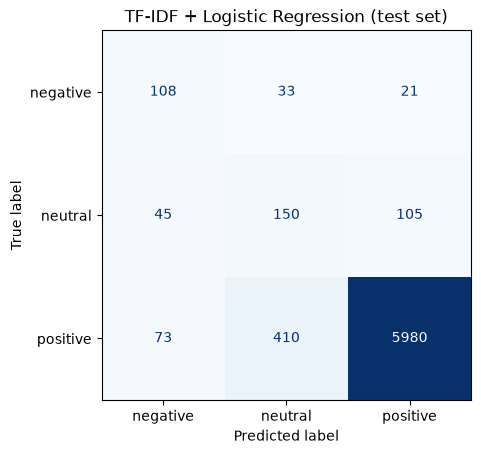

[[ 108   33   21]
 [  45  150  105]
 [  73  410 5980]]


In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues", colorbar=False)
plt.title("TF-IDF + Logistic Regression (test set)")
plt.savefig("../Reports/02_confusion_matrix_tfidf.png")
plt.show()
print(cm)

In [6]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=2)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

param_grid = {
    "tfidf__ngram_range": [(1, 2), (1, 3)],
    "clf__C": [1, 3, 10],
}

search = GridSearchCV(pipe, param_grid, cv=5, scoring="f1_macro", n_jobs=-1)
search.fit(X_train, y_train)

print(search.best_params_, round(search.best_score_, 3))
table = pd.DataFrame(search.cv_results_)[["param_tfidf__ngram_range", "param_clf__C", "mean_test_score"]]
print(table.sort_values("mean_test_score", ascending=False).round(3))

{'clf__C': 3, 'tfidf__ngram_range': (1, 3)} 0.641
  param_tfidf__ngram_range  param_clf__C  mean_test_score
3                   (1, 3)             3            0.641
5                   (1, 3)            10            0.636
2                   (1, 2)             3            0.635
4                   (1, 2)            10            0.629
1                   (1, 3)             1            0.627
0                   (1, 2)             1            0.617


In [7]:
model = search.best_estimator_
test_pred = model.predict(X_test)
print(classification_report(y_test, test_pred, digits=3))

              precision    recall  f1-score   support

    negative      0.550     0.611     0.579       162
     neutral      0.316     0.437     0.366       300
    positive      0.974     0.954     0.964      6463

    accuracy                          0.924      6925
   macro avg      0.613     0.667     0.637      6925
weighted avg      0.936     0.924     0.929      6925



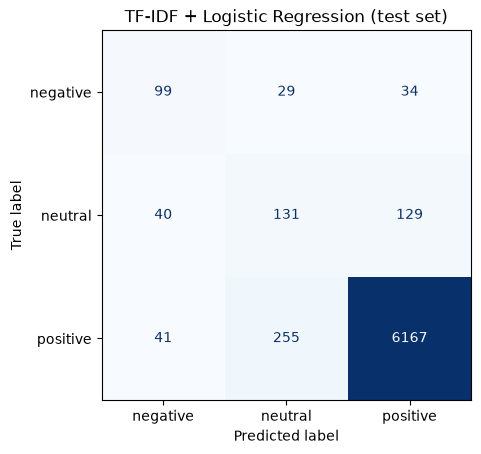

[[  99   29   34]
 [  40  131  129]
 [  41  255 6167]]


In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues", colorbar=False)
plt.title("TF-IDF + Logistic Regression (test set)")
plt.savefig("../Reports/02_confusion_matrix_tfidf.png")
plt.show()
print(cm)

In [9]:
import joblib

joblib.dump(model, "../Models/sentiment_model.joblib")

loaded = joblib.load("../Models/sentiment_model.joblib")
print(loaded.predict(["It broke after two days. Terrible."]))

['negative']


In [10]:
import sklearn
print(sklearn.__version__)

1.9.1


In [11]:
import joblib
import gradio as gr

model = joblib.load("../Models/sentiment_model.joblib")

def predict(review):
    probabilities = model.predict_proba([review])[0]
    return {label: float(p) for label, p in zip(model.classes_, probabilities)}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(lines=4, label="Paste a product review"),
    outputs=gr.Label(label="Sentiment"),
    title="Customer Review Sentiment",
    examples=[["I love this tablet, the screen is sharp."], ["Stopped charging after two weeks."]],
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
